In [ ]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
    HyperFluxFNO,
)
from context_flux_no.models.multiphysics.hyperfluxfno import HyperFluxFNOv1
from context_flux_no.training import PDEDataset
from context_flux_no.training.loader import (
    SegmentLoader,
    SegmentLoaderBackground,
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray

In [2]:
# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_default_device", jax.devices("gpu")[3])
datadir = Path("../../data")
# dataset_xr = xr.load_dataset(
#     datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf"
# )
dataset_xr = xr.open_mfdataset(
    sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
    combine="nested",
    concat_dim="pde",
    engine="h5netcdf",
).isel(t=slice(None, None, 10))
dataset_xr

<xarray.Dataset> Size: 8GB
Dimensions:  (pde: 1000, ic: 100, t: 101, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 8GB dask.array<chunksize=(100, 100, 101, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 24kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [ ]:
dataset_xr.chunk({"pde": -1, "ic": -1, "t": -1, "x": 1, "dim": 1}).to_netcdf(
    datadir / "cubic_no_source_large_train.hdf5",
    encoding={"values": {"chunksizes": (1000, 100, 101, 1, 1)}},
    engine="h5netcdf",
)

NameError: name 'dataset_xr' is not defined

In [5]:
datadir = Path("../../data")
dataset_xr = xr.open_dataset(
    datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf", chunks={}
).isel({"t": slice(0, 80)})
dataset_xr

<xarray.Dataset> Size: 6GB
Dimensions:  (pde: 1000, ic: 100, t: 80, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 640B 0.0 0.005 0.01 0.015 ... 0.38 0.385 0.39 0.395
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 6GB dask.array<chunksize=(1000, 100, 80, 1, 1), meta=np.ndarray>
    coeffs   (pde, param) float64 24kB dask.array<chunksize=(1000, 3), meta=np.ndarray>

0.005

In [5]:
dataloader = SegmentLoaderBackground(
    dataset_xr, segment_length=21, batch_size=1024, batches_per_load=50
)
# dataiter = iter(dataloader)

In [6]:
arr = next(dataiter)
(arr.dtype.itemsize * arr.size) * 5 / (1024 * 1024)

41.015625

In [17]:
arr.shape

(1024, 21, 1, 100)

In [ ]:
# LossFunction[M: eqx.Module, B: PyTree] = Callable[[M, B, Any, PRNGKeyArray], FloatScalar]

In [6]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "hyperfluxfno"},
)

In [8]:
trainer.train(dpot, dataloader, None, None, num_steps=500, seed=0)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W0311 00:57:48.822796  806357 hlo_rematerialization.cc:3204] Can't reduce memory use below 59.30GiB (63675933655 bytes) by rematerialization; only reduced to 85.49GiB (91792605216 bytes), down from 85.49GiB (91792605216 bytes) originally
W0311 00:57:59.119131  804582 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 85.49GiB (rounded to 91792343552)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0311 00:57:59.119664  804582 bfc_allocator.cc:513] ******______________________________________________________________________________________________
E0311 00:58:04.919825  804582 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Step: 1 | Train loss: 0.7571708559989929 | Valid loss: 
            None
Step: 2 | Train loss: 0.6422528028488159 | Valid loss: 
            None


Step: 3 | Train loss: 0.48261022567749023 | Valid loss: 
            None


Step: 4 | Train loss: 0.3332812786102295 | Valid loss: 
            None


...

Step: 495 | Train loss: 0.0009151232079602778 | Valid loss: 
            None
Step: 496 | Train loss: 0.0009746081777848303 | Valid loss: 
            None


Step: 497 | Train loss: 0.0009704132680781186 | Valid loss: 
            None


Step: 498 | Train loss: 0.00095559743931517 | Valid loss: 
            None


Step: 499 | Train loss: 0.000996286515146494 | Valid loss: 
            None
Step: 500 | Train loss: 0.0010046104434877634 | Valid loss: 
            None


train_loss,█▅▅▄▄▃▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
train_loss,0.001


In [49]:
rng = np.random.default_rng(0)
inds_traj = rng.integers(0, 10000, size=(40, 1024))
inds_t0 = rng.integers(0, rolled.sizes["t"] - 20, size=(40, 1024))


def load_single(dataset, idx_traj, idx_t0, segment_length):
    return dataset.isel(
        {
            "traj": idx_traj,
            "t": idx_t0 + segment_length - 1,
        }
    )


load_single(
    rolled["values"],  # .chunk({"x": 5, "segment": 1, "traj": -1, "t": -1}),
    xr.DataArray(inds_traj, dims=["metabatch", "batch"]),
    xr.DataArray(inds_t0, dims=["metabatch", "batch"]),
    21,
)  # .compute().to_numpy()


<xarray.DataArray 'values' (metabatch: 40, batch: 1024, dim: 1, x: 100,
                            segment: 21)> Size: 688MB
dask.array<transpose, shape=(40, 1024, 1, 100, 21), dtype=float64, chunksize=(40, 1024, 1, 20, 21), chunktype=numpy.ndarray>
Coordinates:
    t        (metabatch, batch) float64 328kB 0.46 0.41 0.47 ... 0.14 0.39 0.455
    traj     (metabatch, batch) object 328kB (85, 6) (63, 69) ... (20, 82)
    pde      (metabatch, batch) int64 328kB 85 63 51 26 30 4 ... 53 62 85 20 20
    ic       (metabatch, batch) int64 328kB 6 69 11 97 78 9 ... 3 13 61 42 25 82
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
Dimensions without coordinates: metabatch, batch, segment

In [4]:
dataset_train, dataset_test = PDEDataset.from_xarray(dataset_xr).split_by_time(80)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


In [8]:
dataset_xr.isel({"t": slice(None, None, 10)})

<xarray.Dataset> Size: 880MB
Dimensions:  (pde: 1000, ic: 100, t: 11, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 88B 0.0 0.05 0.1 0.15 0.2 0.25 0.3 0.35 0.4 0.45 0.5
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 880MB dask.array<chunksize=(100, 100, 11, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float64 24kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [5]:
dataset_train

PDEDataset(
  u=f64[1000,100,80,1,100](numpy),
  t=f64[80](numpy),
  x=f64[100](numpy),
  coeffs=f64[1000,3](numpy),
  dim_names=[np.str_('u')],
  coeff_names=[np.str_('a'), np.str_('b'), np.str_('c')]
)

In [9]:
loader = SegmentLoader(
    dataset_train,
    segment_length=21,
    batch_size=50,
    batching_strategy="consecutive_segments",
)
batch, _ = loader.load_batch(loader.init())

In [10]:
batch[0].shape

(50, 21, 1, 100)

In [7]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    in_timesteps=20,
    patch_size=(4,),
    img_size=(100,),
    embedding_dim=256,
    max_frequency_modes=(10,),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=256,
    hidden_dim_fno=256,
    hidden_dim_output=32,
    key=jax.random.key(0),
)
dpot.num_parameters()  # 0.238M

2383469

In [ ]:
disco = DISCO(
    num_spatial_dims=1,
    channels=1,
    embedding_dim=48,
    patch_size=100,
    num_hypernet_blocks=2,
    droppath=0.1,
    num_hypernet_heads=2,
    mlp_hidden_dim=48,
    boundary_condition="periodic",
    key=jax.random.key(0),
)
disco.num_parameters()  # 0.807M

8067638

In [6]:
hyperfluxfno = HyperFluxFNO(
    data_dim=1,  # Rename argument to channels
    depth=4,
    frequency_modes=10,
    lift_dim=48,
    context_embed_dim=48,
    stencil_size=(2, 1),
    patch_size=(5, 25),
    hypernet_init="bias-hyperinit",
    num_hidden_patch=1,
    key=jax.random.key(0),
)
hyperfluxfno.num_parameters()  # 0.577M

5771057

In [5]:
hyperfluxfno = HyperFluxFNOv1(
    data_dim=1,  # Rename argument to channels
    depth=4,
    frequency_modes=7,
    lift_dim=48,
    context_embed_dim=48,
    stencil_size=(7, 7),
    patch_size=(5, 25),
    hypernet_init="bias-hyperinit",
    num_hidden_patch=1,
    key=jax.random.key(0),
)
hyperfluxfno.num_parameters()  # 0.438M

4378673

In [7]:
dx = dataset_train.x[1] - dataset_train.x[0]
dt = dataset_train.t[1] - dataset_train.t[0]
dt

np.float64(0.005)

In [8]:
eqx.filter_value_and_grad(loss_fn, has_aux=True)(
    hyperfluxfno, batch, (dt, dx), jax.random.key(0)
)

E0302 18:49:23.961429  131263 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0302 18:49:32.280782  131263 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


((Array(0.00293537, dtype=float32), {}),
 HyperFluxFNOv1(
   context_module=ViTContextModule(
     patch_embedding=PatchEmbedding(
       layers=(
         Conv(
           num_spatial_dims=2,
           weight=f32[48,2,5,25],
           bias=f32[48,1,1],
           in_channels=2,
           out_channels=48,
           kernel_size=(5, 25),
           stride=(5, 25),
           padding=((0, 0), (0, 0)),
           dilation=(1, 1),
           groups=1,
           use_bias=True,
           padding_mode='ZEROS'
         ),
         Conv(
           num_spatial_dims=2,
           weight=f32[48,48,1,1],
           bias=f32[48,1,1],
           in_channels=48,
           out_channels=48,
           kernel_size=(1, 1),
           stride=(1, 1),
           padding=((0, 0), (0, 0)),
           dilation=(1, 1),
           groups=1,
           use_bias=True,
           padding_mode='ZEROS'
         )
       ),
       num_spatial_dims=2,
       patch_size=(5, 25),
       in_dim=2,
       embedding_d

In [9]:
def train(
    model: AbstractMultiphysicsOperator,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    args=None,
    max_steps: int = 5000,
    *,
    key: PRNGKeyArray = jax.random.key(0),
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_, key_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        key_, key_next = jax.random.split(key_)

        (loss, aux), grads = loss_grad_fn(model_, batch, args, key_)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next, key_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    # try:
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state, key = train_step(
            model, loader_state, opt_state, key
        )

        loss_scalar = loss.item()
        print(f"Step: {i}: loss = {loss_scalar}")
        loss_history.append(loss_scalar)
    # finally:
    return model, jnp.asarray(loss_history)

'26-03-10-20:28:58'

In [10]:
optimizer = optax.adamw(1e-3)
model, loss_history = train(
    hyperfluxfno, loader, optimizer, loss_fn, (dt, dx), max_steps=5000
)

Step: 0: loss = 0.002935372292995453
Step: 1: loss = 0.0028411548119038343
Step: 2: loss = 0.002760393312200904
Step: 3: loss = 0.003365863114595413
Step: 4: loss = 0.0029762976337224245
Step: 5: loss = 0.00303493975661695
Step: 6: loss = 0.0027892019134014845
Step: 7: loss = 0.002999324817210436
Step: 8: loss = 0.0029060186352580786
Step: 9: loss = 0.003044714219868183
Step: 10: loss = 0.002935644704848528
Step: 11: loss = 0.0030037122778594494
Step: 12: loss = 0.002950392197817564
Step: 13: loss = 0.003207210451364517
Step: 14: loss = 0.00280118640512228
Step: 15: loss = 0.002992098918184638
Step: 16: loss = 0.0030689185950905085
Step: 17: loss = 0.0029250222723931074
Step: 18: loss = 0.002854363527148962
Step: 19: loss = 0.0028151636943221092
Step: 20: loss = 0.0028392113745212555
Step: 21: loss = 0.002781972521916032
Step: 22: loss = 0.0028313477523624897
Step: 23: loss = 0.002834423677995801
Step: 24: loss = 0.0027842260897159576
Step: 25: loss = 0.002896669087931514
Step: 26: los

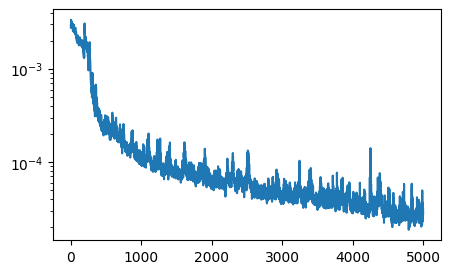

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log")

## Evaluate training results

In [29]:
loader_test = SegmentLoader(dataset_test, segment_length=21, batch_size=1024)

batch_test, _ = loader_test.load_batch(loader_test.init())
model: AbstractMultiphysicsOperator = eqx.nn.inference_mode(model)
u1_pred = eqx.filter_vmap(lambda u_: model(u_, (dt, dx), key=jax.random.key(0)))(
    batch_test[0][:, :-1]
)[0]
u1_data = batch_test[0][:, -1]

In [1]:
sample_idx = 10

fig, axes = plt.subplots(2, 1, figsize=(5, 3), sharex=True, height_ratios=(2, 1))
axes[0].plot(dataset_test.x, u1_data[sample_idx, 0], label="Data")
axes[0].plot(dataset_test.x, u1_pred[sample_idx, 0], label="Pred")

axes[1].plot(dataset_test.x, u1_pred[sample_idx, 0] - u1_data[sample_idx, 0])

NameError: name 'plt' is not defined

In [ ]:
fig, ax

In [42]:
u_rollout_pred = eqx.filter_vmap(
    lambda u_: model.rollout(u_, (dt, dx), num_steps=20, key=jax.random.key(0))
)(batch_test[0][:, :-1])[0]

In [43]:
u_rollout_pred.shape

(1024, 20, 1, 100)

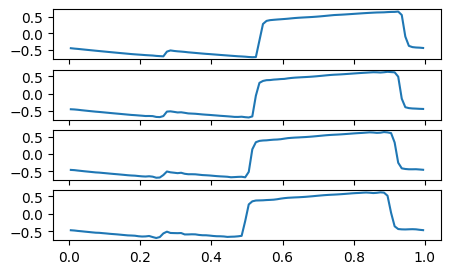

In [49]:
fig, axes = plt.subplots(4, 1, figsize=(5, 3), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(dataset_test.x, u_rollout_pred[sample_idx, 5 * i, 0])